Using 600 samples for heatmap.


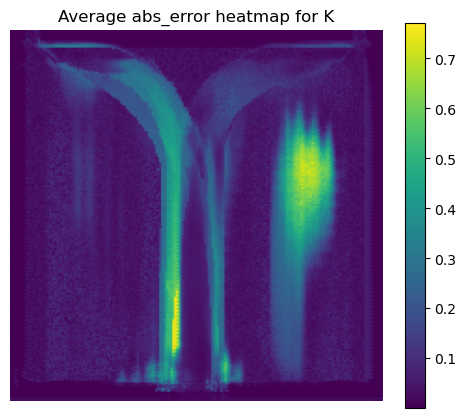

In [5]:
import os
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

import datasets
import metrics

from model_loader import make_model, DEVICE, ChannelSelectDataset


# ------------------------------------------------------------
# User settings
# ------------------------------------------------------------



CHANNEL_NAMES = {
    0: "K",
    1: "P",
    2: "phi",
}


# ------------------------------------------------------------
# Model loading
# ------------------------------------------------------------

def load_trained_model(model_type, model_path, channels="KP"):
    model = make_model(
        model_type=model_type,
        channels=channels,
    )

    state = torch.load(
        model_path,
        map_location=DEVICE,
        weights_only=False,
    )

    model.load_state_dict(state)
    model.eval()

    return model


# ------------------------------------------------------------
# Dataset creation
# ------------------------------------------------------------

def make_dataset(
    sims,
    dataset_mode="border",
    channels="KP",
    full_target=True,
):
    sims = np.array(sims)

    if full_target:
        if dataset_mode == "border":
            base_dataset = datasets.BorderDenseDatasetFull(
                sims=sims,
                channels="all",
            )
        elif dataset_mode == "fixed":
            base_dataset = datasets.FixedDenseDatasetFull(
                sims=sims,
                channels="all",
            )
        else:
            raise ValueError(f"Unknown dataset_mode: {dataset_mode}")

    else:
        if dataset_mode == "border":
            base_dataset = datasets.BorderDenseDatasetLimited(
                sims=sims,
                channels="all",
            )
        elif dataset_mode == "fixed":
            base_dataset = datasets.FixedDenseDatasetLimited(
                sims=sims,
                channels="all",
            )
        else:
            raise ValueError(f"Unknown dataset_mode: {dataset_mode}")

    return ChannelSelectDataset(base_dataset, channels=channels)


# ------------------------------------------------------------
# Index helpers
# ------------------------------------------------------------

def indices_from_sims_and_steps(dataset, sims=None, steps=None, type_index=0):
    """
    Converts sim IDs and step numbers into dataset indices.

    Dense dataset ordering:
        idx = type_i * n_sims * T + sim_i * T + step_i
    """

    dataset_sims = list(dataset.sims)
    T = dataset.num_steps()
    n_sims = len(dataset_sims)

    if sims is None:
        sims = dataset_sims

    if steps is None:
        steps = range(T)

    indices = []

    for sim in sims:
        if sim not in dataset_sims:
            print(f"Skipping sim {sim}: not found in dataset.sims")
            continue

        sim_i = dataset_sims.index(sim)

        for step in steps:
            if step < 0 or step >= T:
                print(f"Skipping step {step}: valid range is 0 to {T - 1}")
                continue

            idx = type_index * n_sims * T + sim_i * T + step
            indices.append(idx)

    return indices


# ------------------------------------------------------------
# Prediction / item handling
# ------------------------------------------------------------

def unpack_dataset_item(item):
    """
    Handles both:
        Full dataset: feat, label
        Limited dataset: feat, label, mask
    """
    if len(item) == 3:
        feat, label, mask = item
    else:
        feat, label = item
        mask = None

    return feat, label, mask


def get_prediction(model, feat):
    with torch.no_grad():
        pred = model(
            feat.unsqueeze(0).to(DEVICE)
        ).squeeze(0).cpu()

    return pred


# ------------------------------------------------------------
# Heatmap computation
# ------------------------------------------------------------

def compute_heatmap_for_item(
    model,
    dataset,
    idx,
    metric="abs_error",
    channel=0,
):
    item = dataset[idx]
    feat, label, mask = unpack_dataset_item(item)

    pred = get_prediction(model, feat)

    pred_b = pred.unsqueeze(0)
    label_b = label.unsqueeze(0)
    label_b = metrics.align_channels(label_b, pred_b)

    if metric == "abs_error":
        heat = metrics.abs_error_map(pred_b, label_b)[0, channel]

    elif metric == "squared_error":
        heat = metrics.mse_map(pred_b, label_b)[0, channel]

    elif metric == "gradient_error":
        heat = metrics.gradient_difference_map(pred_b, label_b)[0, channel]

    elif metric == "darcy_pred":
        heat = torch.abs(metrics.darcy_residual_map(pred_b))[0, 0]

    elif metric == "darcy_true":
        heat = torch.abs(metrics.darcy_residual_map(label_b))[0, 0]

    elif metric == "darcy_match":
        pred_res = metrics.darcy_residual_map(pred_b)
        true_res = metrics.darcy_residual_map(label_b)
        heat = ((pred_res - true_res) ** 2)[0, 0]

    else:
        raise ValueError(
            "metric must be one of: "
            "'abs_error', 'squared_error', 'gradient_error', "
            "'darcy_pred', 'darcy_true', 'darcy_match'"
        )

    return heat.detach().cpu()


def average_heatmap(
    model,
    dataset,
    indices,
    metric="abs_error",
    channel=0,
):
    heatmaps = []

    for idx in indices:
        heat = compute_heatmap_for_item(
            model=model,
            dataset=dataset,
            idx=idx,
            metric=metric,
            channel=channel,
        )
        heatmaps.append(heat)

    return torch.stack(heatmaps).mean(dim=0)


# ------------------------------------------------------------
# Plotting
# ------------------------------------------------------------

def make_heatmap_title(metric, channel):
    if metric in ["abs_error", "squared_error", "gradient_error"]:
        channel_name = CHANNEL_NAMES.get(channel, f"channel {channel}")
        return f"Average {metric} heatmap for {channel_name}"

    return f"Average {metric} heatmap"


def plot_heatmap(
    heatmap,
    title="Heatmap",
    save_path=None,
):
    plt.figure(figsize=(6, 5))
    plt.imshow(heatmap.numpy())
    plt.colorbar()
    plt.title(title)
    plt.axis("off")

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True) if Path(save_path).parent != Path(".") else None
        plt.savefig(save_path, bbox_inches="tight", dpi=200)

    plt.show()


def plot_model_heatmap(
    model,
    dataset,
    indices,
    metric="abs_error",
    channel=0,
    save_path=None,
):
    heatmap = average_heatmap(
        model=model,
        dataset=dataset,
        indices=indices,
        metric=metric,
        channel=channel,
    )

    title = make_heatmap_title(metric, channel)

    plot_heatmap(
        heatmap,
        title=title,
        save_path=save_path,
    )

    return heatmap


# ------------------------------------------------------------
# Main example
# ------------------------------------------------------------
MODEL_TYPE = "splitnet"
CHANNELS = "KP"

MODEL_PATH = "limited_prior_tests2/border_splitnet_physics_limited_mask_mse_darcy_tvP_stats_best_state.pt"

DATASET_MODE = "border"   # "fixed" or "border"
EVAL_FULL_TARGET = True   # use Full dataset for true full-image labels

SIMS = [250, 251, 252]
STEPS = range(0, 200)

METRIC = "abs_error"      # "abs_error", "squared_error", "gradient_error", "darcy_pred", "darcy_true", "darcy_match"
CHANNEL = 0               # 0 = K, 1 = P

SAVE_PATH = "heatmap_abs_error_K.png"


if __name__ == "__main__":

    model = load_trained_model(
        model_type=MODEL_TYPE,
        model_path=MODEL_PATH,
        channels=CHANNELS,
    )

    dataset = make_dataset(
        sims=SIMS,
        dataset_mode=DATASET_MODE,
        channels=CHANNELS,
        full_target=EVAL_FULL_TARGET,
    )

    indices = indices_from_sims_and_steps(
        dataset=dataset,
        sims=SIMS,
        steps=STEPS,
    )

    print(f"Using {len(indices)} samples for heatmap.")

    heatmap = plot_model_heatmap(
        model=model,
        dataset=dataset,
        indices=indices,
        metric=METRIC,
        channel=CHANNEL,
        save_path=SAVE_PATH,
    )

In [ ]:
METRIC = "abs_error"       # visual absolute error
METRIC = "squared_error"   # MSE-style error map
METRIC = "gradient_error"  # where structural/edge gradients are wrong
METRIC = "darcy_pred"      # Darcy residual of prediction
METRIC = "darcy_true"      # Darcy residual of true label
METRIC = "darcy_match"     # where predicted physics residual differs from true residual